In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import seaborn as sns   

plt.style.use("default")


In [2]:
housing=fetch_california_housing()

In [4]:
print(housing.DESCR[:1000])


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [5]:
print(housing.data.shape)
print(housing.target.shape  )

(20640, 8)
(20640,)


In [6]:
df=pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)
df['Price']=housing.target

In [7]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
df.info

<bound method DataFrame.info of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       

In [9]:
df.describe

<bound method NDFrame.describe of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

     

In [10]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

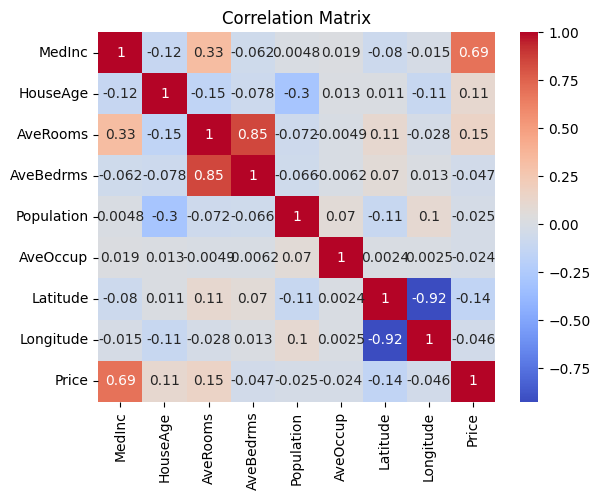

In [12]:
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"   
)

plt.title("Correlation Matrix")

plt.savefig("images/correlation_heatmap.png")
plt.show()

In [13]:
X=df.drop("Price",axis=1)
y=df["Price"]

In [14]:
print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [15]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,
    random_state=42
)


In [16]:
linear_model=LinearRegression()

linear_model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
train_pred=linear_model.predict(X_train)
test_pred=linear_model.predict(X_test)   

In [18]:
print("Train R²: ",r2_score(y_train,train_pred))
print("Test R²: ",r2_score(y_test,test_pred))


Train R²:  0.609873031052925
Test R²:  0.5910509795491354


In [19]:
from sklearn.metrics import root_mean_squared_error

print("Train RMSE: ",root_mean_squared_error(y_train,train_pred))

print("Test RMSE: ",root_mean_squared_error(y_test,test_pred))

Train RMSE:  0.7214930466501481
Test RMSE:  0.7356145375446766


In [20]:
poly=PolynomialFeatures(
    degree=2,
    include_bias=False
)


In [31]:
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [32]:
print("Original Shape: ",X_train.shape)
print("Polynomial: ",X_train_poly.shape)

Original Shape:  (15480, 8)
Polynomial:  (15480, 44)


In [33]:
from sklearn.linear_model import LinearRegression

poly_linear = LinearRegression()

poly_linear.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
train_pred_poly = poly_linear.predict(X_train_poly)

test_pred_poly = poly_linear.predict(X_test_poly)

In [35]:
print(type(X_train_poly))
print(type(X_test_poly))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [37]:
print(X_train_poly.shape)
print(X_test_poly.shape)

print(type(poly))
print(type(X_test_poly))

(15480, 44)
(5160, 44)
<class 'sklearn.preprocessing._polynomial.PolynomialFeatures'>
<class 'numpy.ndarray'>


In [38]:
poly_linear = LinearRegression()

poly_linear.fit(X_train_poly, y_train)

train_pred_poly = poly_linear.predict(X_train_poly)
test_pred_poly = poly_linear.predict(X_test_poly)

print("Polynomial Linear Regression")
print("----------------------------")
print("Train R² :", r2_score(y_train, train_pred_poly))
print("Test R²  :", r2_score(y_test, test_pred_poly))

print("Train RMSE :", np.sqrt(mean_squared_error(y_train, train_pred_poly)))
print("Test RMSE  :", np.sqrt(mean_squared_error(y_test, test_pred_poly)))

Polynomial Linear Regression
----------------------------
Train R² : 0.6829089327528398
Test R²  : 0.6563005879298475
Train RMSE : 0.6504608570751245
Test RMSE  : 0.6743806675010929


In [39]:
ridge=Ridge(alpha=1.0)

ridge.fit(X_train_poly,y_train)

c:\Users\kamal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.5761475255923084e-19.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [40]:

train_pred_ridge = ridge.predict(X_train_poly)
test_pred_ridge = ridge.predict(X_test_poly)

print("Polynomial + Ridge")
print("------------------")
print("Train R² :", r2_score(y_train, train_pred_ridge))
print("Test R²  :", r2_score(y_test, test_pred_ridge))

print("Train RMSE :", np.sqrt(mean_squared_error(y_train, train_pred_ridge)))
print("Test RMSE  :", np.sqrt(mean_squared_error(y_test, test_pred_ridge)))

Polynomial + Ridge
------------------
Train R² : 0.6793189687718951
Test R²  : 0.6730142087157953
Train RMSE : 0.6541326080498825
Test RMSE  : 0.6577792327799665


In [41]:
comparison = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Polynomial Linear",
        "Polynomial Ridge"
    ],

    "Train R²":[
        r2_score(y_train, train_pred),
        r2_score(y_train, train_pred_poly),
        r2_score(y_train, train_pred_ridge)
    ],

    "Test R²":[
        r2_score(y_test, test_pred),
        r2_score(y_test, test_pred_poly),
        r2_score(y_test, test_pred_ridge)
    ],

    "Train RMSE":[
        np.sqrt(mean_squared_error(y_train, train_pred)),
        np.sqrt(mean_squared_error(y_train, train_pred_poly)),
        np.sqrt(mean_squared_error(y_train, train_pred_ridge))
    ],

    "Test RMSE":[
        np.sqrt(mean_squared_error(y_test, test_pred)),
        np.sqrt(mean_squared_error(y_test, test_pred_poly)),
        np.sqrt(mean_squared_error(y_test, test_pred_ridge))
    ]
})

comparison

,Model,Train R²,Test R²,Train RMSE,Test RMSE
0,Linear Regression,0.609873,0.591051,0.721493,0.735615
1,Polynomial Linear,0.682909,0.656301,0.650461,0.674381
2,Polynomial Ridge,0.679319,0.673014,0.654133,0.657779


In [45]:
comparison.to_csv(
    "model_results.csv",
    index=False
)

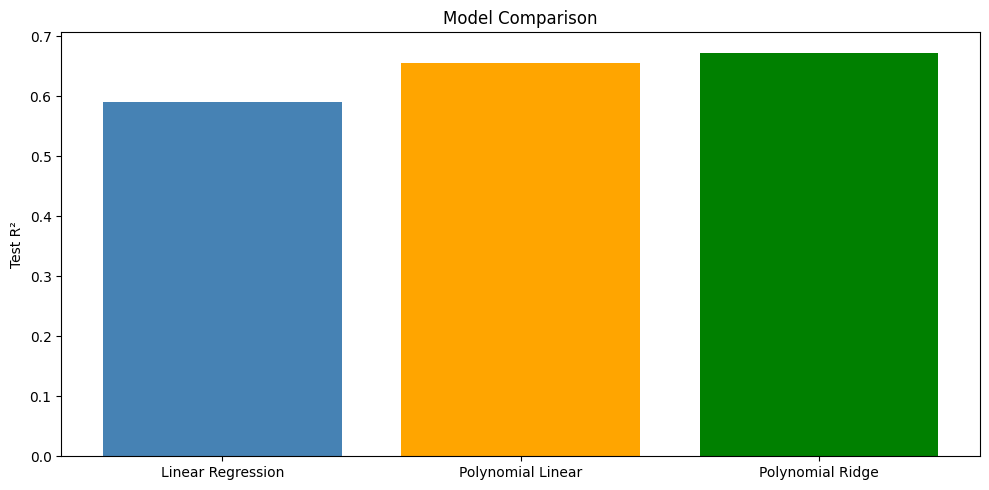

In [48]:
plt.figure(figsize=(10,5))

plt.bar(
    comparison["Model"],
    comparison["Test R²"],
    color=["steelblue","orange","green"]
)

plt.ylabel("Test R²")
plt.title("Model Comparison")

plt.tight_layout()


plt.show()

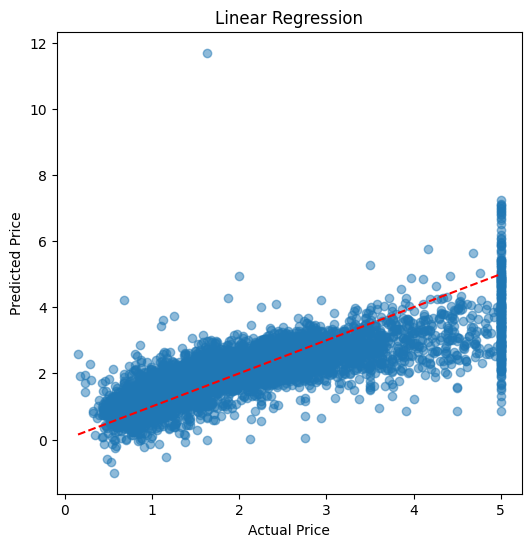

In [49]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    test_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Linear Regression")

plt.savefig(
    "images/actual_vs_predicted_linear.png",
    dpi=300
)

plt.show()

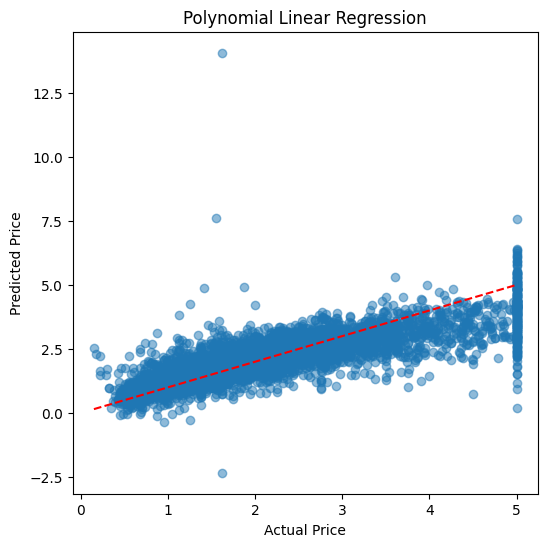

In [52]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    test_pred_poly,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Polynomial Linear Regression")

plt.savefig(
    "images/actual_vs_predicted_poly.png",
    dpi=300
)

plt.show()

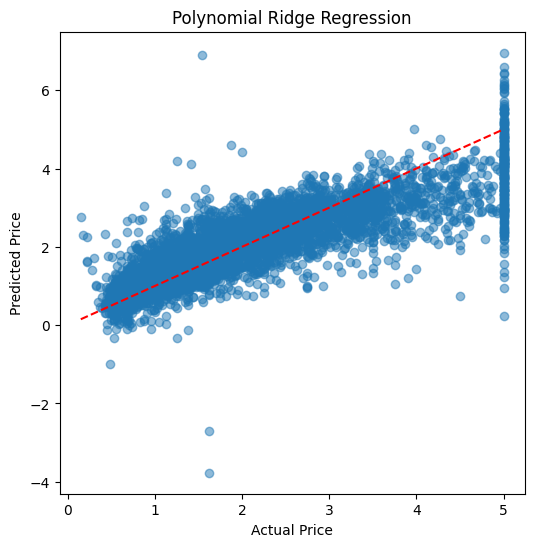

In [53]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    test_pred_ridge,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Polynomial Ridge Regression")

plt.savefig(
    "images/actual_vs_predicted_ridge.png",
    dpi=300
)

plt.show()

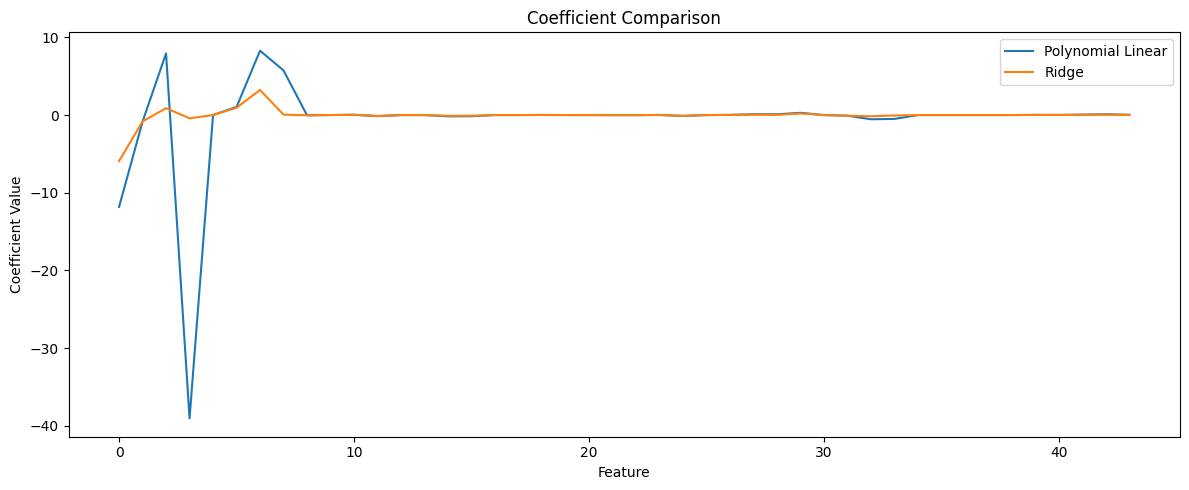

In [54]:
plt.figure(figsize=(12,5))

plt.plot(
    poly_linear.coef_,
    label="Polynomial Linear"
)

plt.plot(
    ridge.coef_,
    label="Ridge"
)

plt.legend()

plt.title("Coefficient Comparison")

plt.xlabel("Feature")

plt.ylabel("Coefficient Value")

plt.tight_layout()

plt.savefig(
    "images/coefficient_comparison.png",
    dpi=300
)

plt.show()

In [55]:
feature_names = poly.get_feature_names_out(X.columns)

coef_df = pd.DataFrame({
    "Feature":feature_names,
    "Coefficient":ridge.coef_
})

coef_df["Abs"] = coef_df["Coefficient"].abs()

coef_df.sort_values(
    "Abs",
    ascending=False
).head(15)

,Feature,Coefficient,Abs
0,MedInc,-5.928314,5.928314
6,Latitude,3.230540,3.230540
5,AveOccup,0.936637,0.936637
2,AveRooms,0.885113,0.885113
1,HouseAge,-0.815822,0.815822
3,AveBedrms,-0.418710,0.418710
29,AveBedrms^2,0.203986,0.203986
32,AveBedrms Latitude,-0.151970,0.151970
11,MedInc AveBedrms,-0.126535,0.126535
24,AveRooms AveBedrms,-0.100107,0.100107
